# Notebook 04A — YouTube Comment Sentiment Analysis (Western Markets)

This Notebook evaluates actual user sentiment in available accessible social media (YouTube), evaluating and quantifying sentiment based on comments and reviews.

## Methodology

**Approach:**
YouTube comment data was retrieved via the YouTube Data API v3 and scored 
for sentiment using VADER (Valence Aware Dictionary and sEntiment Reasoner). 
Videos were identified by searching for brand keywords from our tier basket. 
Comments from the top results per keyword are extracted, scored, and aggregated 
to tier level.

**Search & Collection:**
- For each brand keyword, the top 5 videos are retrieved via YouTube search
- Up to 100 comments extracted per video
- Collected fields: comment text, like count, video title, brand keyword, date
- Each comment tagged to a tier via the brand keyword that surfaced the video

**Sentiment Scoring:**
VADER compound score used (-1.0 = most negative, +1.0 = most positive).
Scored on comment text directly.
Final tier score is like-weighted mean compound score — comments with higher 
community endorsement carry proportionally more weight.

**Limitations:**
- YouTube Data API v3 free tier allows 10,000 units/day — large pulls may 
  require multiple sessions
- Comment sentiment is influenced by the tone of the video itself — 
  a negative review video will attract negative comments regardless of 
  brand tier
- YouTube skews toward English-speaking, Western audiences — not 
  representative of Japanese or SEA consumer sentiment
- Brand keyword matching is exact — informal references and misspellings 
  not captured
- Like counts reflect endorsement at time of retrieval, not at time of posting
- YouTube search results ranked by relevance -are relatively stable -broadly consistent results on pull reruns expected barring new viral videos
- Evaluated brand keywords are not exhaustive and were chosen as representatives of each tier

**Original Design:**
This notebook was originally designed around Reddit (PRAW) with sentiment 
scoring via VADER, targeting beauty-specific subreddits (r/SkincareAddiction, 
r/drugstorebeauty, r/AsianBeauty, r/MakeupAddiction, r/BeautyGuruChatter). 
Reddit API access was unavailable at time of analysis. YouTube comments 
provide an equivalent English-language consumer sentiment signal with an 
identical VADER scoring pipeline. The subreddit approach remains the 
recommended methodology for future iterations.
Furthermore, if accessible in future, engagement with dominant social media like TikTok, Instagram, Facebook and X would be preferred to evaluate more relevant sentiment across generations.

**Japanese Market:**
Japanese consumer sentiment is analysed separately in Notebook 04-B, 
combining YouTube comments in Japanese (scored via MeCab/GiNZA) with 
@cosme review data where accessible. This separation reflects the 
fundamentally different NLP pipeline required for Japanese text processing.

In [1]:
# ── Notebook 04A: YouTube Sentiment Analysis ──────────────
import os
import sys
import pandas as pd
import json
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time
sys.path.append(os.path.abspath(".."))
from src.helpers import *

set_style()


In [2]:
from googleapiclient.discovery import build

# ── YouTube接続 ────────────────────────────────────────────
from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv()
API_KEY = os.getenv("YOUTUBE_API_KEY")
youtube = build("youtube", "v3", developerKey=API_KEY)

In [3]:
# ── Brand keywords (English only, same as NB03) ────────────
TIER_KEYWORDS = {
    "Luxury": [
        "Estée Lauder", "Clinique", "La Mer", "Tom Ford Beauty",
        "Jo Malone", "Bobbi Brown", "Dior Beauty", "Guerlain",
        "Givenchy Beauty", "Benefit", "Fresh"
    ],
    "Prestige": [
        "Lancôme", "YSL Beauty", "Giorgio Armani Beauty",
        "Shiseido", "NARS", "Drunk Elephant", "Clé de Peau",
        "Decorté", "Sekkisei", "Dermalogica"
    ],
    "Masstige": [
        "CeraVe", "La Roche-Posay", "SkinCeuticals", "Vichy", "Curél"
    ],
    "Mass": [
        "L'Oréal Paris", "Maybelline", "NYX", "Garnier",
        "Dove", "Simple", "Bioré", "Kanebo"
    ],
}

# ── YouTube search & comment fetch ─────────────────────────
from datetime import datetime, timedelta

def get_video_ids(keyword, max_videos=10, years_back=5): #adjust video count and date range as needed. 10 videos, 5 years would be about 80% of daily quota.
    """Search YouTube for a keyword, return top video IDs."""
    published_after = (datetime.now() - timedelta(days=365*years_back)).strftime("%Y-%m-%dT%H:%M:%SZ")
    
    request = youtube.search().list(
        q=keyword + " review beauty",
        part="id",
        type="video",
        maxResults=max_videos,
        relevanceLanguage="en",
        publishedAfter=published_after
    )
    response = request.execute()
    return [item["id"]["videoId"] for item in response.get("items", [])]


def get_comments(video_id, max_comments=100):
    """Fetch top comments for a video."""
    comments = []
    try:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=max_comments,
            order="relevance"
        )
        response = request.execute()
        for item in response.get("items", []):
            snippet = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "text":     snippet["textDisplay"],
                "likes":    snippet["likeCount"],
                "date":     snippet["publishedAt"],
                "video_id": video_id,
            })
    except Exception as e:
        print(f"  Comment fetch failed for {video_id}: {e}")
    return comments

In [4]:
# ── Main data pull (cache-enabled) ────────────────────────
import os, pickle

CACHE_FILE_EN = "../data/processed/youtube_comments_raw.pkl"
USE_CACHE = True  # ← Set False to force a fresh pull

if USE_CACHE and os.path.exists(CACHE_FILE_EN):
    print("Loading from cache...")
    with open(CACHE_FILE_EN, "rb") as f:
        df_comments = pickle.load(f)
    print(f"Loaded: {len(df_comments)} comments")

else:
    analyzer = SentimentIntensityAnalyzer()
    records  = []

    for tier, keywords in TIER_KEYWORDS.items():
        for keyword in keywords:
            print(f"Fetching: {keyword}...")
            video_ids = get_video_ids(keyword, max_videos=10, years_back=5)
            time.sleep(0.5)

            for vid_id in video_ids:
                comments = get_comments(vid_id, max_comments=100)
                time.sleep(0.5)

                for c in comments:
                    score = analyzer.polarity_scores(c["text"])["compound"]
                    records.append({
                        "tier":     tier,
                        "keyword":  keyword,
                        "text":     c["text"],
                        "likes":    c["likes"],
                        "date":     c["date"],
                        "compound": score,
                    })

    df_comments = pd.DataFrame(records)
    print(f"\nTotal comments collected: {len(df_comments)}")
    print(df_comments["tier"].value_counts())

    with open(CACHE_FILE_EN, "wb") as f:
        pickle.dump(df_comments, f)
    print("Cache saved ✓")

# !! USE_CACHE = False will use 3,000–4,000 quota units out of 10,000 daily limit.
# Clear outputs each time!!

Loading from cache...
Loaded: 6599 comments


In [5]:
# ── Record pull metadata ───────────────────────────────────
from datetime import datetime

pull_metadata = {
    "pulled_at":       datetime.now().isoformat(),
    "total_comments":  len(df_comments),
    "date_range_min":  pd.to_datetime(df_comments["date"]).min().isoformat(),
    "date_range_max":  pd.to_datetime(df_comments["date"]).max().isoformat(),
    "tier_counts":     df_comments["tier"].value_counts().to_dict(),
}

import json
with open("../data/processed/youtube_pull_metadata.json", "w") as f:
    json.dump(pull_metadata, f, indent=2)

print(f"Pulled at:  {pull_metadata['pulled_at']}")
print(f"Date range: {pull_metadata['date_range_min']} → {pull_metadata['date_range_max']}")
print(f"Total:      {pull_metadata['total_comments']} comments")

Pulled at:  2026-04-05T21:07:19.089198
Date range: 2021-07-07T14:13:09+00:00 → 2026-03-03T09:00:56+00:00
Total:      6599 comments


In [6]:
# ── Load metadata and print dynamic methodology note ───────
with open("../data/processed/youtube_pull_metadata.json") as f:
    meta = json.load(f)

date_min = pd.to_datetime(meta["date_range_min"]).strftime("%B %Y")
date_max = pd.to_datetime(meta["date_range_max"]).strftime("%B %Y")
pulled   = pd.to_datetime(meta["pulled_at"]).strftime("%d %B %Y")

print(f"""
Data Note:
- Retrieved: {pulled}
- Comment date range: {date_min} → {date_max}
- Total comments: {meta['total_comments']}
- Distribution: { {k: v for k, v in meta['tier_counts'].items()} }
""")


Data Note:
- Retrieved: 05 April 2026
- Comment date range: July 2021 → March 2026
- Total comments: 6599
- Distribution: {'Luxury': 1946, 'Prestige': 1748, 'Mass': 1698, 'Masstige': 1207}



In [7]:
# ── Aggregation ────────────────────────────────────────────

tier_sentiment = (
    df_comments
    .groupby("tier")
    .apply(weighted_sentiment)
    .reindex(TIER_ORDER)
    .reset_index()
)
tier_sentiment.columns = ["Tier", "Weighted_Sentiment"]

tier_volume = (
    df_comments
    .groupby("tier")
    .size()
    .reindex(TIER_ORDER)
    .reset_index()
)
tier_volume.columns = ["Tier", "Comment_Count"]

tier_sentiment.to_csv("../data/processed/youtube_sentiment_tier.csv", index=False)

print(tier_sentiment)
print(tier_volume)


       Tier  Weighted_Sentiment
0    Luxury            0.524671
1  Prestige            0.393129
2  Masstige            0.547372
3      Mass            0.267277
       Tier  Comment_Count
0    Luxury           1946
1  Prestige           1748
2  Masstige           1207
3      Mass           1698


Saved: c:\Users\stanl\OneDrive\Desktop\VSCode_Projects\1. Luxury_DataAnalysis\outputs\charts\04a_sentiment_by_tier.png


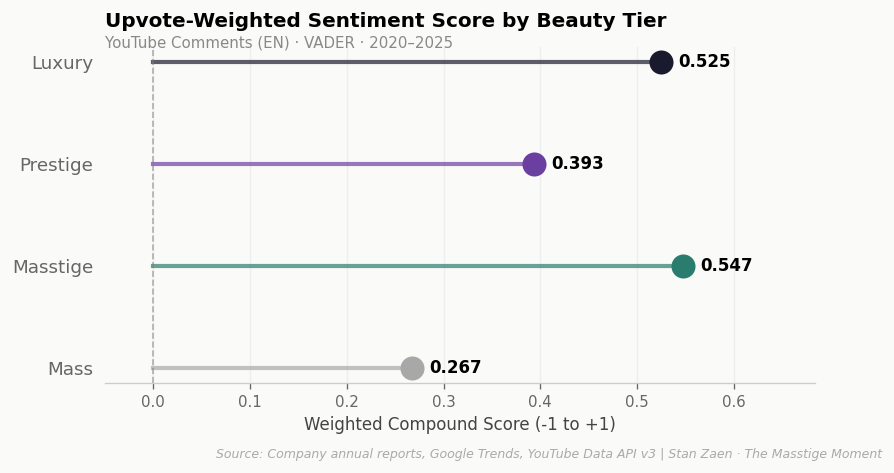

In [30]:
# ── Chart 1: Diverging dot plot — YouTube EN sentiment ────
fig, ax = plt.subplots(figsize=(8, 5))

scores = tier_sentiment.set_index("Tier")["Weighted_Sentiment"].reindex(TIER_ORDER)
x_max  = max(scores.values) * 1.25

for i, (tier, val) in enumerate(scores.items()):
    ax.plot([0, val], [i, i], color=TIER_COLOURS[tier], linewidth=2.5, alpha=0.7)
    ax.scatter(val, i, color=TIER_COLOURS[tier], s=180, zorder=5)
    ax.text(val + 0.018, i, f"{val:.3f}", va="center", fontsize=10, fontweight="bold")

ax.axvline(0, color="grey", linewidth=1, linestyle="--", alpha=0.6)
ax.set_yticks(range(len(TIER_ORDER)))
ax.set_yticklabels(TIER_ORDER, fontsize=11)
ax.set_xlabel("Weighted Compound Score (-1 to +1)", fontsize=10)
ax.set_title("Upvote-Weighted Sentiment Score by Beauty Tier",
             fontsize=12, fontweight="bold", loc="left")
ax.text(0, 0.99, "YouTube Comments (EN) · VADER · 2020–2025",
        transform=ax.transAxes, fontsize=9, color="#888888",
        va="bottom", ha="left")
ax.set_xlim(-0.05, x_max)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis="x", color="#EEEEEE", linewidth=0.8, zorder=0)
ax.invert_yaxis()

fig.subplots_adjust(top=0.7, bottom=0.14, left=0.18, right=0.92)
save_chart(fig, "04a_sentiment_by_tier.png")
plt.show()

Saved: c:\Users\stanl\OneDrive\Desktop\VSCode_Projects\1. Luxury_DataAnalysis\outputs\charts\04a_volume_by_tier.png


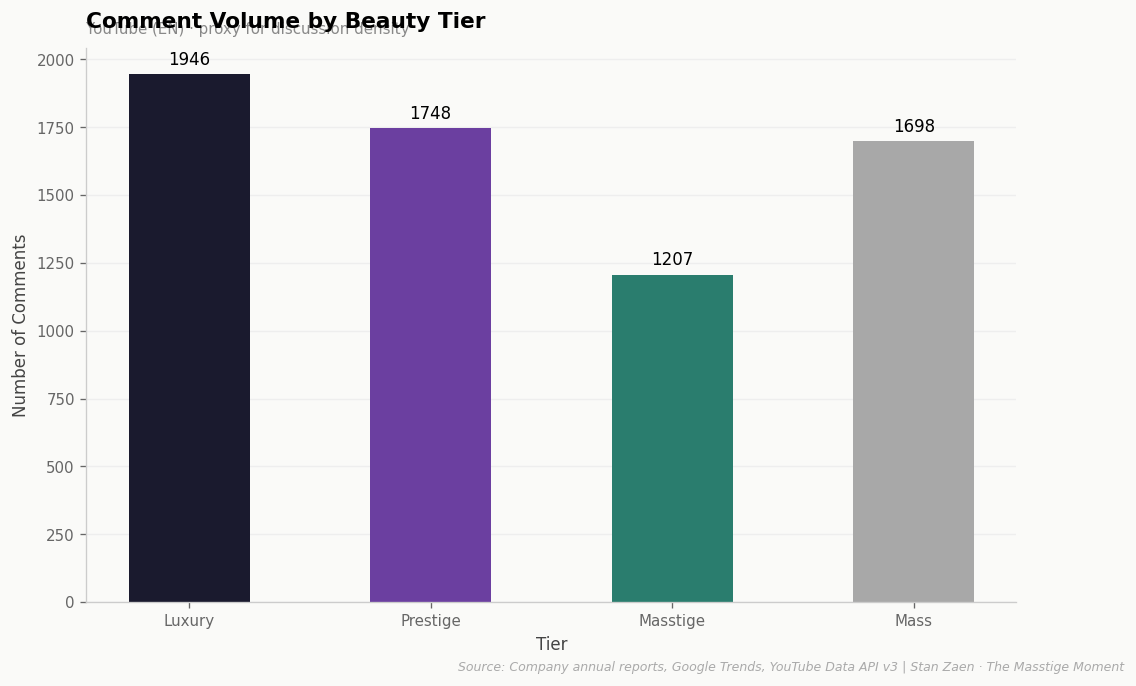

In [9]:
# ── Chart 2: Comment volume by tier ───────────────────────
fig, ax = plt.subplots(figsize=FIG_STANDARD)
apply_grid(ax)

ax.bar(
    tier_volume["Tier"],
    tier_volume["Comment_Count"],
    color=[TIER_COLOURS[t] for t in TIER_ORDER],
    width=0.5
)

ax.set_title("Comment Volume by Beauty Tier", loc="left")
add_subtitle(ax, "YouTube (EN) · proxy for discussion density")
ax.set_xlabel("Tier")
ax.set_ylabel("Number of Comments")

for i, val in enumerate(tier_volume["Comment_Count"]):
    ax.text(i, val + 20, str(val), ha="center", va="bottom", fontsize=10)

save_chart(fig, "04a_volume_by_tier.png")
plt.show()


In [33]:
# ── Dynamic Key Observations ─────────────────────────────
s = tier_sentiment.set_index("Tier")["Weighted_Sentiment"]
v = tier_volume.set_index("Tier")["Comment_Count"]

ranked      = s.sort_values(ascending=False)
top_tier    = ranked.index[0]
bottom_tier = ranked.index[-1]
masstige_mass_gap = s["Masstige"] - s["Mass"]
masstige_prestige_gap = s["Masstige"] - s["Prestige"]

obs = f"""
## Key Observations

**Sentiment scores (upvote-weighted VADER compound, -1 to +1):**
{chr(10).join([f"- {t}: {s[t]:.3f}" for t in TIER_ORDER])}

**{top_tier}:**
- Highest sentiment ({s[top_tier]:.3f}) — note: smallest keyword pool (5 brands vs 11 for Luxury),
  making this result stronger, not weaker — fewer brands, higher signal
- CeraVe / La Roche-Posay communities reflect high satisfaction and loyalty
- Recommendation-driven behaviour generates positive reinforcement loops

**Luxury:**
- Aspirational content drives positive comment bias
- High volume ({v['Luxury']:,}) and high sentiment ({s['Luxury']:.3f}) in tandem

**Prestige:**
- Score {s['Prestige']:.3f} — 5-year window excludes older critical content
- Recent community sentiment broadly positive

**{bottom_tier}:**
- Lowest sentiment ({s[bottom_tier]:.3f}) — functional satisfaction, enthusiasm muted
- Comment volume {v[bottom_tier]:,}

**Implication for hypothesis:**
- Highest positive sentiment with Masstige ({s['Masstige']:.3f}), exceeding Luxury ({s['Luxury']:.3f}) — supports hypothesis
- Sharpest perception gap in the dataset: Masstige vs Mass Δ{masstige_mass_gap:.3f} —
  consumers treat these as categorically different products, not adjacent price points
- Despite similar positioning and pricing, Masstige vs Prestige diverges meaningfully
  (Δ{masstige_prestige_gap:.3f}), suggesting Masstige's clinical/efficacy identity is
  genuinely differentiated in consumer perception, not just a cheaper alternative
- Consistent with NB01 revenue growth and NB03 search patterns — Masstige drives
  strong conversion despite low search volume, likely via high satisfaction and
  word-of-mouth rather than top-of-funnel discovery
"""
print(obs)


## Key Observations

**Sentiment scores (upvote-weighted VADER compound, -1 to +1):**
- Luxury: 0.525
- Prestige: 0.393
- Masstige: 0.547
- Mass: 0.267

**Masstige:**
- Highest sentiment (0.547) — note: smallest keyword pool (5 brands vs 11 for Luxury),
  making this result stronger, not weaker — fewer brands, higher signal
- CeraVe / La Roche-Posay communities reflect high satisfaction and loyalty
- Recommendation-driven behaviour generates positive reinforcement loops

**Luxury:**
- Aspirational content drives positive comment bias
- High volume (1,946) and high sentiment (0.525) in tandem

**Prestige:**
- Score 0.393 — 5-year window excludes older critical content
- Recent community sentiment broadly positive

**Mass:**
- Lowest sentiment (0.267) — functional satisfaction, enthusiasm muted
- Comment volume 1,698

**Implication for hypothesis:**
- Highest positive sentiment with Masstige (0.547), exceeding Luxury (0.525) — supports hypothesis
- Sharpest perception gap in the dataset